# Équité (fairness) en classification supervisée

**Intervenante** : Flore Vancompernolle Vromman

**Durée estimée** : 1h10

**Objectifs d'apprentissage**
- Comprendre pourquoi un modèle « aveugle » à l'attribut sensible peut quand même discriminer
- Savoir d'où viennent les biais (données, labels, échantillonnage, proxys)
- Mesurer l'équité : matrice de confusion, accuracy et equalized odds (TPR, FPR) par groupe, puis demographic parity et disparate impact
- Comprendre le compromis entre équité et performance
- Savoir qu'on peut agir à trois stades : pre-processing, in-processing, post-processing
- Implémenter une méthode de post-processing simple pour réduire les disparités

**Pré-requis :** Module ML du J2 (features, train/test, accuracy/precision/recall, matrice de confusion).

**Packages requis :** `scikit-learn`, `pandas`, `numpy`, `matplotlib`

## Le running example : Law School (rappel du J2)

On reprend le dataset **Law School** (LSAC, Wightman 1998) et le modèle entraîné au J2 : une **régression logistique** qui prédit `y_pass_bar` (réussite à l'examen du barreau, 0/1) à partir des seules features `x_*` (LSAT, GPA undergrad, temps plein, revenu familial, tier de la faculté).

La nouveauté du jour : l'**attribut sensible** `z_white`.

| Valeur | Groupe |
|---|---|
| `z_white = 1` | personnes **blanches** (groupe majoritaire) |
| `z_white = 0` | personnes **non-blanches** (groupe minorisé) |

Point crucial : `z_white` **n'a jamais été utilisé comme feature** par le modèle. On parle de *fairness through unawareness* (« équité par ignorance »). On va voir que **ça ne suffit pas** : le modèle produit malgré tout des décisions très différentes selon le groupe.

On ne ré-entraîne rien : on repart des **prédictions déjà calculées** sur le jeu de test (`data/law_school/output/`). Pour chaque individu, le fichier contient :
- la **vérité terrain** : `y_pass_bar` (1 = a réussi le barreau, 0 = a échoué) ;
- la **classe prédite** par le modèle : `y_pred` (1 = accepté, 0 = refusé) ;
- la **probabilité prédite** de réussite : `y_proba_pass` (un nombre entre 0 et 1) ;
- l'**attribut sensible** : `z_white` (le groupe d'appartenance, jamais utilisé comme feature).

## Setup

In [16]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score

In [31]:
# On repart des PRÉDICTIONS déjà calculées par le modèle du J2 (régression logistique).
# Colonnes : z_white (sensible), y_pass_bar (vérité), y_pred (classe prédite), y_proba_pass (proba de réussite)
URL = "https://raw.githubusercontent.com/mickaeltemporao/lillelms/main/data/law_school"
df = pd.read_csv(f"{URL}/output/predictions_classification_test.csv")

print(f"{len(df):,} individus dans le jeu de test")
df.head()

4,673 individus dans le jeu de test


,id,x_lsat,x_ugpa,x_fulltime,x_fam_inc,x_tier,z_white,y_pass_bar,y_pred,y_proba_pass
0,0,42.0,3.0,1,3.0,3,1,1,1,0.957360
1,1,40.0,3.2,1,4.0,4,1,1,1,0.956237
2,2,41.0,3.5,1,4.0,5,1,1,1,0.971511
3,3,38.0,3.2,1,3.0,6,1,0,1,0.933686
4,4,33.0,3.1,1,3.0,3,1,1,1,0.861376


In [18]:
# Taille relative des deux groupes (le groupe minorisé z_white=0 est très minoritaire)
df["z_white"].value_counts(normalize=True).round(3)

z_white
1    0.84
0    0.16
Name: proportion, dtype: float64

## 1. Pourquoi se soucier de l'équité ?

Un modèle de classification, c'est une machine à **trier** des personnes. À partir d'un dossier (les features), il range chacune dans une catégorie. Dans notre exemple, il prédit pour chaque étudiant·e « va réussir le barreau » ou « va échouer ». Ce genre de décision automatique est de plus en plus utilisé pour des choses qui changent une vie : accorder un crédit, sélectionner des CV à l'embauche, fixer une caution, prioriser des patient·es aux urgences.

Le problème, c'est que rien ne garantit que le modèle traite tous les groupes de la même manière. Il peut, sans qu'on l'ait voulu, **refuser beaucoup plus souvent** les personnes d'un certain groupe. C'est ce qu'illustre le schéma ci-dessous : à partir des mêmes dossiers, le modèle (les engrenages) accepte surtout un groupe (flèche verte) et refuse surtout l'autre (flèche rouge).

<img src="img/classification-discrimination.png" width="620" alt="Un modèle de classification qui discrimine un groupe">

*À partir des mêmes dossiers, un modèle peut systématiquement défavoriser un groupe. Ici, les personnes représentées en foncé « sont discriminées » : elles sont surtout refusées.*

Un **attribut sensible** (ou *protégé*) est une caractéristique sur laquelle la loi ou l'éthique interdit de discriminer : origine, genre, âge, religion, handicap. Dans ce notebook, ce sera `z_white` (la personne est blanche ou non).

On pourrait croire qu'il suffit de **cacher** cet attribut au modèle pour éviter toute discrimination. C'est l'idée de la *fairness through unawareness* (« équité par ignorance »), et c'est exactement ce qui a été fait au J2 : `z_white` n'a jamais servi de feature. Pourtant, **ça ne suffit pas**. D'autres features sont **corrélées** à l'origine : on les appelle des **proxys**. Le revenu familial, le rang de la faculté ou le score au LSAT contiennent indirectement de l'information sur l'origine sociale et ethnique. Le modèle peut donc reconstituer le groupe « par la bande » et discriminer sans jamais avoir vu l'attribut sensible.

Vérifions tout de suite que ces proxys existent vraiment dans nos données : il suffit de mesurer la **corrélation** entre `z_white` et chaque feature. Une corrélation non nulle signale une feature qui « fuit » de l'information sur le groupe.

In [19]:
# Les features x_* sont incluses dans le fichier : sont-elles corrélées à z_white ?
# Une corrélation non nulle => la feature est un PROXY (elle "fuit" de l'info sur le groupe).
features = ["x_lsat", "x_ugpa", "x_fulltime", "x_fam_inc", "x_tier"]
df[features].corrwith(df["z_white"]).sort_values().round(3)

x_fulltime    0.030
x_tier        0.081
x_ugpa        0.283
x_fam_inc     0.305
x_lsat        0.517
dtype: float64

La corrélation est loin d'être nulle pour plusieurs features. Le proxy le plus fort est de loin le **score LSAT** (`x_lsat`, l'examen d'aptitude standardisé passé pour entrer en faculté de droit), avec une corrélation ≈ 0,52. Viennent ensuite le **revenu familial** (`x_fam_inc`, le niveau de revenu déclaré de la famille, ≈ 0,31) et le **GPA undergrad** (`x_ugpa`, la moyenne des notes obtenues avant la faculté de droit, ≈ 0,28). Seuls `x_fulltime` et `x_tier` sont quasi décorrélés.

Autrement dit, même sans jamais voir `z_white`, le modèle dispose à travers ces features d'une image indirecte assez nette du groupe d'appartenance. C'est exactement pour ça que la *fairness through unawareness* ne suffit pas : cacher l'attribut sensible n'efface pas l'information, elle subsiste dans les **proxys**. On ne peut donc pas se contenter d'**espérer** que le modèle est juste, il faut le **mesurer**. C'est tout l'objet de la section 3.

## 2. D'où viennent les discriminations ?

Avant de mesurer, essayons de comprendre **d'où** viennent les biais. Souvent, ils existent **avant même** le modèle : ils sont déjà dans le monde et dans les données. Voici les sources les plus courantes.

| Source | En clair | Exemple dans Law School |
|---|---|---|
| Biais **historique / sociétal** | la réalité mesurée est déjà inégalitaire | accès inégal à la préparation au barreau selon l'origine |
| Biais dans les **labels** | la cible `y` reflète des décisions humaines déjà biaisées | conditions de passage de l'examen défavorables à certains groupes |
| Biais d'**échantillonnage** | un groupe est sous-représenté, donc le modèle l'apprend moins bien | `z_white = 0` ne pèse que 16 % du dataset |
| **Proxys** | des features sont corrélées à l'attribut sensible | revenu familial, rang de la faculté, score LSAT |
| **Boucles de rétroaction** | les décisions du modèle nourrissent les données futures | refuser un groupe réduit ses données, ce qui renforce le biais au tour suivant |

Vérifions tout de suite une chose simple sur nos données : la disparité existe-t-elle **déjà dans la réalité**, avant même de parler du modèle ?

In [20]:
# Pour chaque groupe : taux de réussite RÉEL (vérité) vs taux d'acceptation du MODÈLE
comparaison = pd.DataFrame({
    "effectif": df.groupby("z_white").size(),
    "réussite réelle (y_pass_bar)": df.groupby("z_white")["y_pass_bar"].mean(),
    "acceptation modèle (y_pred)": df.groupby("z_white")["y_pred"].mean(),
}).round(3)
comparaison

,effectif,réussite réelle (y_pass_bar),acceptation modèle (y_pred)
z_white,,,
0,149,0.168,0.094
1,785,0.563,0.614


On tire deux enseignements de ce tableau :

1. Le **taux de réussite réel** est déjà très différent entre les deux groupes (environ 0,17 contre 0,56). Une grande partie de l'inégalité est donc **déjà présente dans les données**, avant même tout modèle.
2. Le modèle **accentue cette disparité** : il refuse davantage que la réalité pour le groupe minorisé (seulement environ 9 % d'acceptation, alors que 17 % réussissent réellement), tandis qu'il accepte un peu plus que la réalité pour le groupe majoritaire (environ 61 % d'acceptation contre 56 % de réussite). L'écart réel (39 points) devient un écart de traitement encore plus grand (52 points). C'est cette différence de traitement qu'on va **quantifier** en section 3.

## 3. Mesurer l'équité

Il n'existe **pas une seule** définition de l'équité, mais plusieurs, qui ne sont pas toujours compatibles entre elles. On va les découvrir une par une et les mesurer sur les prédictions du modèle.

Notations utilisées dans la suite :
- **Y** : la vérité terrain (`y_pass_bar`), ce qui s'est réellement passé (la personne a réussi ou non).
- **Ŷ** : la décision du modèle (`y_pred`), ce qu'il a prédit.
- **Z** : l'attribut sensible (`z_white`), le groupe d'appartenance.

On va d'abord regarder les métriques **basées sur la matrice de confusion** (qui comparent la décision à la vérité terrain), puis celles qui ne regardent **que les décisions** du modèle.

### 3.1 La matrice de confusion, par groupe

La **matrice de confusion** (vue au J2) croise ce que la personne a réellement fait avec ce que le modèle a prédit. On reprend le même tableau qu'au module ML du J2 :

|  | Prédit 1 (passe) | Prédit 0 (rate) |
|---|---|---|
| **Réel 1 (passe)** | TP (vrai positif) | FN (faux négatif) |
| **Réel 0 (rate)**  | FP (faux positif) | TN (vrai négatif) |

Dans notre cas, ces quatre cases ont un sens très concret :
- **Vrai positif (TP)** : le modèle prédit « réussite » et la personne réussit vraiment.
- **Faux positif (FP)** : le modèle prédit « réussite » mais la personne échoue en réalité (un faux espoir).
- **Faux négatif (FN)** : le modèle prédit « échec » mais la personne aurait réussi (une occasion manquée).
- **Vrai négatif (TN)** : le modèle prédit « échec » et la personne échoue vraiment.

L'idée centrale de tout le notebook : on calcule cette matrice **séparément pour chaque groupe**. Une matrice globale fait une moyenne sur tout le monde et masque les écarts entre groupes.

In [21]:
for z, nom in [(0, "Z = 0 (personnes non-blanches, groupe minorisé)"),
               (1, "Z = 1 (personnes blanches)")]:
    sous = df[df["z_white"] == z]
    # labels=[1, 0] : même orientation que le tableau ci-dessus (classe positive en premier)
    cm = confusion_matrix(sous["y_pass_bar"], sous["y_pred"], labels=[1, 0])
    print(f"\n{nom} (n = {len(sous)})")
    print(pd.DataFrame(
        cm,
        index=["réel 1 (passe)", "réel 0 (rate)"],
        columns=["prédit 1 (passe)", "prédit 0 (rate)"],
    ))


Z = 0 (personnes non-blanches, groupe minorisé) (n = 149)
                prédit 1 (passe)  prédit 0 (rate)
réel 1 (passe)                 4               21
réel 0 (rate)                 10              114

Z = 1 (personnes blanches) (n = 785)
                prédit 1 (passe)  prédit 0 (rate)
réel 1 (passe)               323              119
réel 0 (rate)                159              184


### 3.2 L'accuracy, par groupe

À partir de cette matrice, on calcule l'**accuracy** (déjà vue au J2). Elle se définit directement à partir des quatre cases :

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Lue sur l'exemple Law School, elle répond à une question simple : sur l'ensemble des personnes d'un groupe, quelle proportion de décisions le modèle a-t-il **correctement** prédites (réussite ou échec bien anticipés) ?

Le point clé pour l'équité : on la calcule **par groupe**. Si le modèle est nettement plus fiable pour un groupe que pour l'autre, il est moins juste, car ses décisions sont moins sûres pour certaines personnes. Commençons par le **groupe majoritaire** (Z = 1).

In [22]:
# Accuracy pour le groupe MAJORITAIRE (Z = 1, personnes blanches)
sous_maj = df[df["z_white"] == 1]
acc_maj = accuracy_score(sous_maj["y_pass_bar"], sous_maj["y_pred"])
print(f"Z = 1 (groupe majoritaire) : accuracy = {acc_maj:.3f}")

Z = 1 (groupe majoritaire) : accuracy = 0.646


### Hack Time

On vient de calculer l'accuracy du **groupe majoritaire** (Z = 1). À votre tour : calculez l'**accuracy du groupe minoritaire** (Z = 0, personnes non-blanches), avec la même fonction `accuracy_score`.
- L'accuracy est-elle **la même** dans les deux groupes ? Quel est l'écart ?
- Pour quel groupe le modèle est-il le **plus fiable** ? À votre avis, pourquoi ? (repensez à la taille des groupes et aux sources de biais vues en section 2)

In [ ]:
# Votre code ici


### 3.3 Equalized odds : se tromper de la même façon dans les deux groupes

L'idée d'*equalized odds* (« chances égales ») : à situation réelle identique, le modèle devrait **se tromper de la même manière** dans les deux groupes. On regarde pour cela deux taux, calculés eux aussi à partir de la matrice de confusion.

- **TPR** (taux de vrais positifs, aussi appelé *recall* au J2) : parmi les personnes qui réussissent **vraiment** le barreau, quelle proportion le modèle prédit comme reçues ? On veut un TPR élevé, et surtout **le même** dans les deux groupes. Exiger uniquement que le TPR soit identique entre les groupes porte d'ailleurs un nom à part : l'**equal opportunity** (« égalité des chances », Hardt et al. 2016).
- **FPR** (taux de faux positifs) : parmi les personnes qui échouent **vraiment**, quelle proportion le modèle prédit (à tort) comme reçues ? Un FPR plus élevé dans un groupe veut dire que le modèle donne de **faux espoirs** surtout à ce groupe.

Comme la demographic parity (section 3.4), ces deux taux s'écrivent aussi comme des **probabilités conditionnelles**, mais cette fois conditionnées à la vérité terrain `Y` :

$$\text{TPR} = \frac{TP}{TP+FN} = P(\hat{Y}=1 \mid Y=1), \qquad \text{FPR} = \frac{FP}{FP+TN} = P(\hat{Y}=1 \mid Y=0)$$

L'**equal opportunity** demande seulement que le **TPR soit identique** dans les deux groupes (sans rien imposer sur le FPR) :

$$P(\hat{Y}=1 \mid Y=1, Z=0) = P(\hat{Y}=1 \mid Y=1, Z=1)$$

L'**equalized odds** est plus exigeant : il demande l'égalité **du TPR et du FPR à la fois** entre les deux groupes.

In [23]:
def tpr_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    tpr = tp / (tp + fn)   # parmi les vraies réussites, % prédites reçues
    fpr = fp / (fp + tn)   # parmi les vrais échecs, % prédites reçues (à tort)
    return tpr, fpr

odds = {}
for z in [0, 1]:
    sous = df[df["z_white"] == z]
    tpr, fpr = tpr_fpr(sous["y_pass_bar"], sous["y_pred"])
    odds[f"Z = {z}"] = {"TPR": tpr, "FPR": fpr}

odds_df = pd.DataFrame(odds).T.round(3)
print(odds_df)
print(f"\nÉcart de TPR entre groupes : {abs(odds['Z = 0']['TPR'] - odds['Z = 1']['TPR']):.3f}")
print(f"Écart de FPR entre groupes : {abs(odds['Z = 0']['FPR'] - odds['Z = 1']['FPR']):.3f}")

         TPR    FPR
Z = 0  0.160  0.081
Z = 1  0.731  0.464

Écart de TPR entre groupes : 0.571
Écart de FPR entre groupes : 0.383


On lit deux choses dans ce tableau :
- Le **FPR est plus élevé pour le groupe majoritaire** (0,46 contre 0,08) : le modèle accepte à tort près de la moitié des majoritaires qui vont échouer, alors qu'il refuse presque tous les minorisés qui vont échouer. Il accorde un **bénéfice du doute** surtout au groupe majoritaire.
- Le **TPR est beaucoup plus faible pour le groupe minorisé** (0,16 contre 0,73) : parmi les personnes qui réussissent vraiment, le modèle n'en **détecte que 16 %** dans le groupe minorisé contre 73 % dans le groupe majoritaire. Ce sont des candidatures méritantes massivement écartées à tort, l'injustice la plus directe.

Les deux taux diffèrent énormément entre les groupes : **equalized odds n'est pas respecté**, et c'est bien le **groupe minorisé qui est désavantagé**.

### Changer de point de vue : les métriques qui ignorent la vérité terrain

Toutes les métriques vues jusqu'ici (accuracy, equalized odds) comparent les décisions du modèle à la **vérité terrain** `y_pass_bar`. Mais on a vu en section 2 que cette vérité peut **elle-même être biaisée** (par exemple si les conditions de passage de l'examen défavorisent un groupe). Les deux métriques suivantes adoptent donc un autre point de vue : elles ne regardent **que les décisions** du modèle, sans supposer que la vérité terrain est juste.

### 3.4 Demographic parity (ou *statistical parity*)

C'est l'idée la plus simple : le modèle devrait **accepter la même proportion** de personnes dans chaque groupe, peu importe qui réussit réellement.

Exemple concret : s'il prédit « réussite » pour 9 % des personnes non-blanches mais 61 % des personnes blanches, il y a un problème de parité, **même si** ces chiffres reflètent des taux de réussite réels différents. Ici, on ne juge que le **traitement** réservé à chaque groupe.

$$P(\hat{Y}=1 \mid Z=0) = P(\hat{Y}=1 \mid Z=1)$$

On mesure l'écart entre ces deux proportions, la **demographic parity difference** : plus il est proche de 0, plus le modèle est paritaire. En pratique, chaque proportion est simplement la **moyenne de `y_pred`** dans le groupe.

In [24]:
taux_pred = df.groupby("z_white")["y_pred"].mean()
dp_diff = abs(taux_pred.loc[1] - taux_pred.loc[0])

print(f"P(accepté | Z=0) = {taux_pred.loc[0]:.3f}")
print(f"P(accepté | Z=1) = {taux_pred.loc[1]:.3f}")
print(f"Demographic parity difference = {dp_diff:.3f}")

P(accepté | Z=0) = 0.094
P(accepté | Z=1) = 0.614
Demographic parity difference = 0.520


### Hack Time

On vient de calculer la parité sur les **décisions du modèle** (`y_pred`). Recalculez le même écart, mais cette fois sur les **vrais résultats** `y_pass_bar`.
- L'écart est-il déjà présent dans la réalité (les vrais taux de réussite) ?
- Le modèle **réduit-il** ou **amplifie-t-il** cette disparité ? (à relier à la section 2)

In [ ]:
# Votre code ici

### 3.5 Disparate impact

C'est la même idée que la demographic parity, mais exprimée comme un **ratio** plutôt qu'une différence. On divise le taux d'acceptation du groupe désavantagé par celui du groupe avantagé :

$$\text{DI} = \frac{P(\hat{Y}=1 \mid Z=0)}{P(\hat{Y}=1 \mid Z=1)}$$

Un ratio de 1 signifie un traitement identique. Plus on descend vers 0, plus le groupe désavantagé est sous-accepté.

**La règle des 4/5 (ou règle des 80 %).** Une convention juridique considère qu'il y a discrimination (*adverse impact*) dès que ce ratio passe **sous 0,8**. Elle vient du droit américain de l'emploi. En machine learning, cette règle a été popularisée notamment par **Feldman et al. (2015)**, *Certifying and Removing Disparate Impact*.

In [ ]:
di = taux_pred.loc[0] / taux_pred.loc[1]   # groupe désavantagé / groupe avantagé
print(f"Disparate impact = {di:.3f}")
if di < 0.8:
    print("Attention : le modèle est discriminant (DI < 0.8)")

Disparate impact = 0.153
Règle des 4/5 (80%) : non-respectée


> **Pas de surprise ici.** Le disparate impact vaut environ 0,15 : il **ne respecte pas** la règle des 80 %, très loin du seuil de 0,8. Ce résultat confirme la forte discrimination détectée par la demographic parity.

### 3.6 Le compromis entre équité et performance

On aimerait un modèle **à la fois** performant (accuracy élevée) **et** équitable (faible écart de parité). Ces deux objectifs sont souvent en **tension** : améliorer l'un peut dégrader l'autre.

Pour les résumer en un seul nombre, on peut les combiner par une **moyenne harmonique**, exactement comme le F1-score combine precision et recall. On note ACC l'accuracy et DP la *demographic parity difference* (donc `1 - DP` mesure la parité, où 1 = parité parfaite) :

$$\mathrm{F1DP} = 2 \,\frac{\mathrm{ACC} \times (1 - \mathrm{DP})}{\mathrm{ACC} + (1 - \mathrm{DP})}$$

Ce score n'est élevé que si le modèle est **en même temps** précis et paritaire.

In [26]:
acc_globale = accuracy_score(df["y_pass_bar"], df["y_pred"])
parite = 1 - dp_diff
f1_dp = 2 * acc_globale * parite / (acc_globale + parite)

print(f"ACC (accuracy globale) : {acc_globale:.3f}")
print(f"1 - DP (parité)        : {parite:.3f}")
print(f"F1_DP (score combiné)  : {f1_dp:.3f}")

ACC (accuracy globale) : 0.669
1 - DP (parité)        : 0.480
F1_DP (score combiné)  : 0.559


## 4. Comment réduire les discriminations ?

Si on mesure qu'il y a des discriminations, on aimerait pouvoir les **réduire**. Pour ça, on peut intervenir à **trois moments différents** du cycle de vie du modèle. Le schéma ci-dessous situe ces trois moments : on agit sur les **données** en entrée, sur l'**algorithme** lui-même, ou sur les **décisions** en sortie.

<img src="img/classification-discrimination-agir.png" width="620" alt="Les trois stades où agir : pre-processing, in-processing, post-processing">

*Trois endroits où agir : sur les données (pre-processing), sur l'algorithme (in-processing) ou sur les décisions finales (post-processing).*

**Pre-processing : agir sur les données, avant l'entraînement.**
On corrige les données d'entraînement avant même de lancer le modèle. Exemple concret : on **repondère** les individus pour donner plus de poids au groupe minorisé, afin que le modèle lui accorde autant d'importance qu'aux autres malgré son faible effectif.
- *Avantage :* on s'attaque à la racine du problème, les données biaisées.
- *Limite :* il faut avoir accès aux données et pouvoir ré-entraîner le modèle.

**In-processing : agir sur l'algorithme, pendant l'entraînement.**
On change la façon dont le modèle apprend, en lui imposant une **contrainte d'équité** directement dans son objectif. Exemple concret : on lui demande de minimiser ses erreurs tout en gardant des taux d'acceptation proches entre les deux groupes.
- *Avantage :* souvent le plus efficace, car l'équité est prise en compte dès l'apprentissage.
- *Limite :* c'est plus technique, et il faut là aussi ré-entraîner le modèle.

**Post-processing : agir sur les décisions, après l'entraînement.**
On garde le modèle tel quel et on ajuste seulement ses **décisions finales**. Exemple concret : on change certaines décisions pour rapprocher les taux d'acceptation des deux groupes.
- *Avantage :* très accessible. On n'a besoin ni des données d'entraînement ni de ré-entraîner : on part juste des prédictions. C'est exactement notre situation aujourd'hui.
- *Limite :* on agit en bout de chaîne, sans corriger la cause profonde du biais.

C'est cette dernière approche, la plus simple, qu'on va implémenter.

## 5. Implémentation : post-processing par swapping

On va corriger les décisions du modèle pour **rapprocher les taux d'acceptation** des deux groupes. La méthode s'appelle le **swapping** (« échange ») : on modifie certaines décisions, une par une.

> Cette méthode est tirée de : Vancompernolle Vromman, F., Courtain, S., Leleux, P., & Saerens, M. (2025). *Fairness-Aware Post-Processing in Supervised Classification: L1/L2 Norm and Optimal Swapping Methods*. Proceedings of the AAAI/ACM Conference on AI, Ethics, and Society, 8(3), 2563-2574. https://doi.org/10.1609/aies.v8i3.36738

Trois principes guident la méthode :
1. On agit **uniquement sur les sorties** du modèle (`y_pred` et la probabilité `y_proba_pass`). On ne ré-entraîne rien.
2. On n'a **aucun réglage à choisir** : pas de paramètre arbitraire à fixer.
3. On n'utilise **jamais la vraie réponse** (`y_pass_bar`) pour décider des swaps. C'est important : se servir de la vérité terrain pour ajuster les décisions reviendrait à tricher, car dans la vraie vie on n'y a pas accès au moment de décider.

**Quels swaps fait-on ?** Le groupe désavantagé est celui qui a le plus faible taux d'acceptation (ici, Z = 0). On a deux façons de rapprocher les taux.

**Swap de type 1 (promotion) :** on prend une personne du groupe désavantagé qui avait été **refusée**, et on l'**accepte**.

<img src="img/swap-promo.png" width="600" alt="Swap de type 1 : promouvoir une personne désavantagée refusée">

*Swap de type 1 : on accepte une personne du groupe discriminé qui avait été refusée.*

**Swap de type 2 (rétrogradation) :** on prend une personne du groupe avantagé qui avait été **acceptée**, et on la **refuse**.

<img src="img/swap-retro.png" width="600" alt="Swap de type 2 : rétrograder une personne avantagée acceptée">

*Swap de type 2 : on refuse une personne du groupe avantagé qui avait été acceptée.*

**Lequel choisir à chaque étape ?** Le **moins coûteux**, c'est-à-dire celui qui touche la décision **la moins sûre**. La probabilité prédite `y_proba_pass` mesure la confiance du modèle : une proba proche de 0,5 veut dire que le modèle hésitait. On swappe donc en priorité les personnes dont la proba est la plus proche de 0,5, car changer leur décision coûte le moins en performance.

On répète l'opération **tant que** le groupe désavantagé reste moins souvent accepté, et on s'arrête quand les deux taux se rejoignent.

In [27]:
def swap_glouton(y_pred, proba, z, y_true, disadv=0, adv=1):
    """Post-processing sans paramètre : on rapproche les taux d'acceptation des
    deux groupes en swappant, une par une, les décisions les MOINS sûres
    (proba la plus proche de 0.5), tant que le groupe désavantagé est sous-accepté.

    y_true ne sert PAS à décider des swaps : il n'est utilisé que pour mesurer
    l'accuracy au fil de l'eau (historique, pour la courbe équité/performance).

    Renvoie : les décisions corrigées + un historique (n_swaps, |DP diff|, accuracy).
    """
    yp = np.asarray(y_pred).copy()
    proba = np.asarray(proba)
    z = np.asarray(z)
    y_true = np.asarray(y_true)

    cout = np.abs(proba - 0.5)                  # distance au seuil 0.5 = coût du swap
    ordre = np.argsort(cout)                     # du moins coûteux au plus coûteux

    # candidats aux deux types de swap, classés du moins au plus coûteux
    type1_promotion = [i for i in ordre if z[i] == disadv and yp[i] == 0]
    type2_retrogradation = [i for i in ordre if z[i] == adv and yp[i] == 1]

    def taux(g):
        return yp[z == g].mean()

    pi = ri = 0
    hist = [(0, abs(taux(adv) - taux(disadv)), accuracy_score(y_true, yp))]

    while taux(adv) - taux(disadv) > 0:
        cout_type1 = cout[type1_promotion[pi]] if pi < len(type1_promotion) else np.inf
        cout_type2 = cout[type2_retrogradation[ri]] if ri < len(type2_retrogradation) else np.inf
        if cout_type1 == np.inf and cout_type2 == np.inf:
            break                                 # plus aucun swap possible
        if cout_type1 <= cout_type2:
            yp[type1_promotion[pi]] = 1            # swap de type 1 : on accepte un désavantagé
            pi += 1
        else:
            yp[type2_retrogradation[ri]] = 0       # swap de type 2 : on refuse un avantagé
            ri += 1
        hist.append((pi + ri, abs(taux(adv) - taux(disadv)), accuracy_score(y_true, yp)))

    hist = pd.DataFrame(hist, columns=["n_swaps", "dp_diff", "accuracy"])
    return yp, hist

In [28]:
y_pred_fair, hist = swap_glouton(
    df["y_pred"], df["y_proba_pass"], df["z_white"], df["y_pass_bar"]
)

taux_apres = pd.Series(y_pred_fair).groupby(df["z_white"].values).mean()
print(f"Swaps effectués    : {int(hist['n_swaps'].iloc[-1])}")
print(f"Taux d'acceptation : Z=0 {taux_pred.loc[0]:.3f} -> {taux_apres.loc[0]:.3f}"
      f"  |  Z=1 {taux_pred.loc[1]:.3f} -> {taux_apres.loc[1]:.3f}")
print(f"DP difference      : {dp_diff:.3f} -> {abs(taux_apres.loc[1] - taux_apres.loc[0]):.3f}")
print(f"Accuracy globale   : {acc_globale:.3f} -> {accuracy_score(df['y_pass_bar'], y_pred_fair):.3f}")

Swaps effectués    : 289
Taux d'acceptation : Z=0 0.094 -> 0.282  |  Z=1 0.614 -> 0.282
DP difference      : 0.520 -> 0.000
Accuracy globale   : 0.669 -> 0.604


La parité est atteinte (DP = 0), mais pour un **coût en accuracy globale sensible** (environ 6 points, de 0,67 à 0,60). L'écart de parité initial étant très grand (0,52), le swapping doit modifier davantage de décisions pour le combler. Comparons maintenant **toutes** les métriques de la section 3, avant et après le swapping :

In [29]:
def resume(y_pred):
    y_pred = np.asarray(y_pred)
    z = df["z_white"].values
    t = pd.Series(y_pred).groupby(z).mean()
    tpr0, fpr0 = tpr_fpr(df["y_pass_bar"][z == 0], y_pred[z == 0])
    tpr1, fpr1 = tpr_fpr(df["y_pass_bar"][z == 1], y_pred[z == 1])
    acc = accuracy_score(df["y_pass_bar"], y_pred)
    dp = abs(t.loc[1] - t.loc[0])
    par = 1 - dp
    return {
        "accuracy globale": acc,
        "accuracy Z=0": accuracy_score(df["y_pass_bar"][z == 0], y_pred[z == 0]),
        "accuracy Z=1": accuracy_score(df["y_pass_bar"][z == 1], y_pred[z == 1]),
        "demographic parity": dp,
        "disparate impact": t.loc[0] / t.loc[1],
        "écart TPR (equal opportunity)": abs(tpr0 - tpr1),
        "écart FPR": abs(fpr0 - fpr1),
        "F1_DP": 2 * acc * par / (acc + par),
    }

pd.DataFrame({
    "avant (modèle brut)": resume(df["y_pred"]),
    "après (swapping)": resume(y_pred_fair),
}).round(3)

,avant (modèle brut),après (swapping)
accuracy globale,0.669,0.604
accuracy Z=0,0.792,0.644
accuracy Z=1,0.646,0.596
demographic parity,0.520,0.000
disparate impact,0.153,1.001
écart TPR (equal opportunity),0.571,0.111
écart FPR,0.383,0.142
F1_DP,0.559,0.753


> **À méditer.** Le swapping a égalisé les taux de demographic parity, mais l'**accuracy du groupe minorisé baisse**, parce qu'on accorde la réussite à des personnes qui échouent en réalité (davantage de faux positifs). « Plus paritaire » n'est donc pas toujours « meilleur ». L'équité est un **choix de société**, pas un simple réglage technique.

### 5bis. La courbe équité / performance

À chaque swap, on a enregistré l'écart de parité et l'accuracy. En les traçant l'un contre l'autre, on visualise le **compromis** : à mesure qu'on gagne en parité (vers la gauche), on perd (un peu) en accuracy.

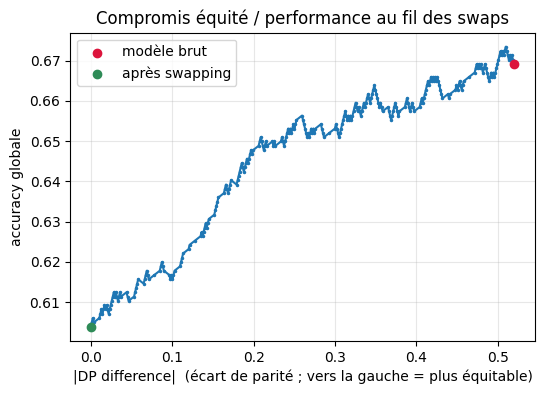

In [30]:
plt.figure(figsize=(6, 4))
plt.plot(hist["dp_diff"], hist["accuracy"], marker=".", markersize=3)
plt.scatter(hist["dp_diff"].iloc[0], hist["accuracy"].iloc[0],
            color="crimson", zorder=5, label="modèle brut")
plt.scatter(hist["dp_diff"].iloc[-1], hist["accuracy"].iloc[-1],
            color="seagreen", zorder=5, label="après swapping")
plt.xlabel("|DP difference|  (écart de parité ; vers la gauche = plus équitable)")
plt.ylabel("accuracy globale")
plt.title("Compromis équité / performance au fil des swaps")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Récap et pour aller plus loin

Ce qu'on a vu aujourd'hui :
- Un modèle **aveugle** à l'attribut sensible peut **quand même discriminer**, via des proxys.
- Les biais ont des sources **multiples**, souvent situées **en amont** du modèle (données, labels, échantillonnage).
- L'équité se **mesure** de plusieurs façons. D'abord avec la matrice de confusion (accuracy et equalized odds), qui se compare à la vérité terrain. Puis avec la demographic parity et le disparate impact, qui ne regardent que les décisions. Ces définitions **ne coïncident pas** entre elles.
- On peut agir à trois stades (**pre / in / post-processing**). Un **swapping** glouton, très simple, suffit à réduire fortement la disparité de parité.
- Mais « réduire un écart » suppose des **choix de valeurs** : qui en bénéficie, qui en paie le prix, quelle définition on privilégie.

**Pour aller plus loin :**
- Ces définitions sont **mathématiquement incompatibles** en général (théorème d'impossibilité, Kleinberg et Chouldechova) : dès que les taux de base diffèrent entre les groupes, on ne peut pas satisfaire en même temps la demographic parity et l'equalized odds.
- D'autres notions d'équité existent comme l'équité **individuelle** plutôt que celle de groupe.
- Des outils dédiés accessibles en ligne : `fairlearn` (`ThresholdOptimizer` en post-processing, `ExponentiatedGradient` en in-processing) et `aif360` (IBM).